In [1]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd

file_path = "cleaned_dataset.csv"
df = pd.read_csv(file_path)

df.head()

,id,source_name,title,author_name,publish_date,accident_date,content,tags,day_of_the_week,time,...,senior_driver_involved,child_involved,senior_involved,visibility,wind_speed,temperature,severity,ambulance_called,additional_source_name,additional_url
0,1,police,Collision between a car and a motorbike in Żur...,NaN,09/10/2025,09/10/2025,"Today, at around 0930hrs, the Police were info...",{},Thursday,morning,...,1.0,0.0,1.0,10.0,3.7,23.0,high,1.0,Weatherspark,https://weatherspark.com
1,2,police,Car-motorcycle traffic accident,NaN,19/06/2025,18/06/2025,"Yesterday, at around 1830hrs, the Police were ...",{},Wednesday,evening,...,1.0,0.0,1.0,10.0,11.1,26.0,high,1.0,NaN,NaN
2,3,police,Car-motorcycle collision in Ħal Qormi,NaN,12/05/2025,12/05/2025,"Today, at around 0800hrs, the Police were info...",{},Monday,morning,...,0.0,0.0,0.0,10.0,27.8,20.0,high,1.0,NaN,NaN
3,4,police,Collision between motorcycle and car in Għaxaq,NaN,30/07/2025,29/07/2025,"Yesterday, at around 1800hrs, the Police were ...",{},Tuesday,evening,...,0.0,0.0,0.0,10.0,38.9,26.0,high,1.0,NaN,NaN
4,5,police,Car-motorcycle collision,NaN,07/04/2025,06/04/2025,"Yesterday, at around quarter to nine in the ev...",{},Sunday,evening,...,0.0,0.0,0.0,10.0,18.5,15.0,high,1.0,NaN,NaN


# Part 2: Individual ML Implementation – Random Forest

## Introduction to Technique
**Random Forest** is an ensemble learning method that builds many decision trees on bootstrapped samples of the training data and aggregates their predictions (majority vote for classification). Each tree is trained on a random subset of features, which decorrelates trees and reduces overfitting.

**Why it is suitable for accident severity prediction:**
- Handles non‑linear relationships and complex feature interactions common in traffic data.
- Robust to noise and outliers compared with single decision trees.
- Works with mixed data types after proper preprocessing.
- Provides **feature importance**, enabling interpretability for policy and safety insights.


In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
#file_path = "/content/drive/My Drive/cleaned_dataset_new.csv"
#df = pd.read_csv(file_path)

df["severity"] = df["severity"].str.lower().str.strip()

# Binary encoding: fatal vs non-fatal
df["fatal"] = df["severity"].apply(lambda x: 1 if x in ["fatal"] else 0)

In [5]:
features = [
    "vehicle_involved",
    "vehicle_count",
    "road_type",
    "min_age",
    "max_age",
    "young_driver_involved",
    "adult_driver_involved",
    "senior_driver_involved",
    "child_involved",
    "visibility",
    "wind_speed",
    "temperature",
    "time_in_hours",
    "rush_hour",
    "weekend_weekday"
]

X = df[features]
y = df["fatal"]

df['fatal'].value_counts()


,count
fatal,
0,246
1,34


## Preprocessing
We prepare the data to ensure the Random Forest can learn effectively:

- **Target engineering:** Accident severity is binarised into *fatal (1)* vs *non‑fatal (0)*.
- **Categorical encoding:** Nominal features (e.g., road type, weather) are one‑hot encoded.
- **Scaling:** Numerical variables are standardised. While Random Forests do not strictly require scaling, this ensures consistency within a pipeline and supports potential comparison with other models.
- **Class imbalance handling:** SMOTE is applied inside the training pipeline to address skewed class distribution and reduce bias toward the majority class.

All preprocessing steps are wrapped in a `ColumnTransformer` and combined with the model in a single `Pipeline` to prevent data leakage.

In [6]:
categorical = ["vehicle_involved", "road_type", "weekend_weekday"]
numeric = [c for c in features if c not in categorical]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", Pipeline([
            ("impute", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
        ]), categorical),

        ("num", Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("scale", StandardScaler())
        ]), numeric)
    ]
)


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)


## Hyperparameter Tuning & Cross‑Validation
We tune key Random Forest hyperparameters using **GridSearchCV** with cross‑validation to identify the best generalisable model. Parameters explored include:

- `n_estimators`: number of trees in the forest
- `max_depth`: maximum depth of each tree
- `min_samples_split` / `min_samples_leaf`: controls overfitting

Cross‑validation ensures performance estimates are not dependent on a single train–test split.

In [8]:
rf_model = RandomForestClassifier(
    random_state=42,
    class_weight="balanced"
)

model = ImbPipeline(steps=[
    ("preprocess", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("rf", rf_model)
])


## Model Evaluation
Performance is assessed using multiple metrics appropriate for imbalanced classification:

- **Accuracy**: overall correctness
- **Precision & Recall**: quality of positive (fatal) predictions
- **F1‑score**: balance between precision and recall
- **ROC‑AUC**: discrimination across thresholds

Visual diagnostics include a **confusion matrix** and **ROC curve**.

In [9]:
param_grid = {
    "rf__n_estimators": [100, 200],
    "rf__max_depth": [None, 10, 20],
    "rf__min_samples_split": [2, 5],
    "rf__min_samples_leaf": [1, 2],
    "rf__max_features": ["sqrt", "log2"]
}

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
best_model = grid_search.best_estimator_


Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best Parameters: {'rf__max_depth': None, 'rf__max_features': 'sqrt', 'rf__min_samples_leaf': 1, 'rf__min_samples_split': 2, 'rf__n_estimators': 100}


In [ ]:
import pickle
import os

rf_model_path = 'models/random-forest/random_forest_model.pkl'

# Make sure the directory exists
os.makedirs(os.path.dirname(rf_model_path), exist_ok=True)

# Save the trained Random Forest model
with open(rf_model_path, 'wb') as file:
    pickle.dump(best_model, file)


In [10]:
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


## Results & Visualisation
The following plots summarise model performance and interpretability:

- Confusion matrix heatmap
- ROC curve
- Feature importance bar chart highlighting variables that most influence fatality prediction.

In [11]:
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.92      0.96      0.94        74
           1       0.57      0.40      0.47        10

    accuracy                           0.89        84
   macro avg       0.75      0.68      0.71        84
weighted avg       0.88      0.89      0.88        84

[[71  3]
 [ 6  4]]


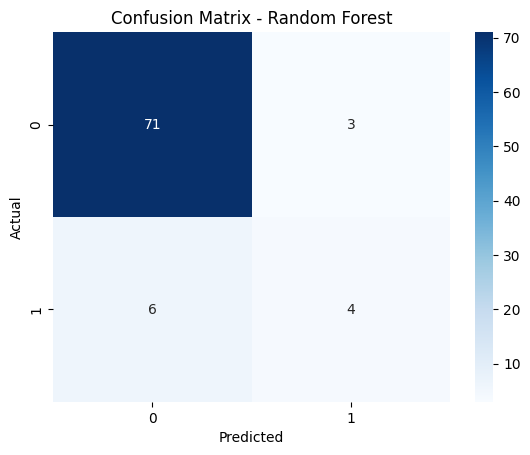

In [12]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()


In [13]:
results = {}

In [14]:
# Save metric results from classification report as dict
results["metric_results"] = classification_report(y_test, y_pred, output_dict=True)
results["actual"] = y_test.tolist()
results["predictions"] = y_pred.tolist()

# Save generated confusion matrix results as dict
results["confusion_matrix"] = {
    "labels": ["0", "1"],
    "matrix": cm.tolist()
}

ROC AUC: 0.8439189189189189


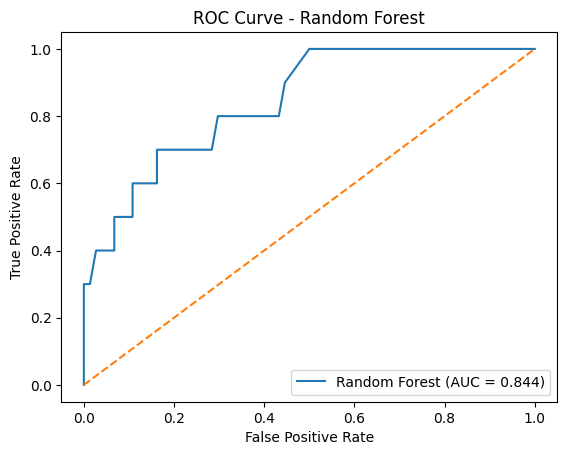

In [15]:
roc_auc = roc_auc_score(y_test, y_proba)
print("ROC AUC:", roc_auc)

fpr, tpr, thresholds = roc_curve(y_test, y_proba)

roc_results_ovrll = {
    "fpr": fpr.tolist(),
    "tpr": tpr.tolist(),
    "thresholds": thresholds.tolist(),
    "roc_auc": float(roc_auc),
    "label": "positive_class"
}

results["roc_curve_ovrll"] = roc_results_ovrll

plt.figure()
plt.plot(fpr, tpr, label=f"Random Forest (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()


In [16]:
feature_names = best_model.named_steps["preprocess"].get_feature_names_out()
importances = best_model.named_steps["rf"].feature_importances_

fi_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

# Save generated feature importances from above as dict
results["model_feature_importances"] = fi_df.to_dict(orient="records")

fi_df.head(15)


,Feature,Importance
44,num__time_in_hours,0.166073
43,num__temperature,0.098013
29,cat__road_type_main road,0.094025
35,num__min_age,0.073974
36,num__max_age,0.067827
11,cat__vehicle_involved_car-motorcycle,0.063060
38,num__adult_driver_involved,0.049007
8,cat__vehicle_involved_car-car,0.044892
16,cat__vehicle_involved_motorcycle,0.041517
33,cat__weekend_weekday_weekend,0.038235


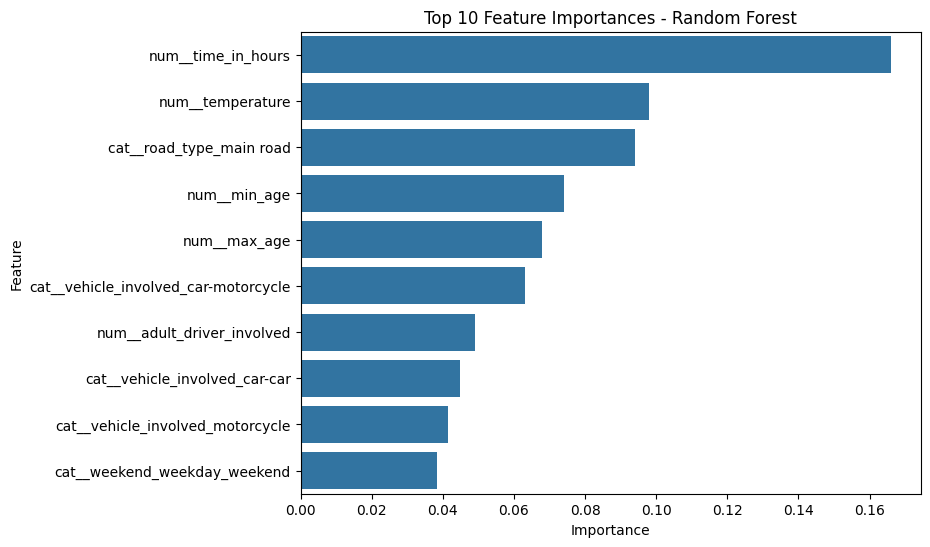

In [17]:
plt.figure(figsize=(8,6))
sns.barplot(data=fi_df.head(10), x="Importance", y="Feature")
plt.title("Top 10 Feature Importances - Random Forest")
plt.show()


In [18]:
import json
# Save results

if not os.path.exists('results'):
    os.makedirs('results')

with open("results/random_forest_results.json", "w") as f:
    json.dump(results, f, indent=4)

## Interpretation
Feature importance indicates which factors most influence fatal accident outcomes. For example:

- **Road and environment variables** (e.g., road type, lighting, weather) often dominate, suggesting that infrastructure and visibility conditions play a critical role in severity.
- **Vehicle involvement and traffic conditions** highlight exposure and collision dynamics.

These insights can inform **targeted interventions** such as improved lighting, road redesign, speed management, and public safety campaigns. While Random Forests are not fully transparent, feature importance offers a meaningful level of interpretability for policy use.

## Limitations & Ethical Considerations
**Limitations:**
- Random Forests are less interpretable than linear models; feature importance does not imply causation.
- Performance depends on data quality; missing or biased reporting can distort results.
- SMOTE may generate synthetic patterns that do not perfectly reflect real‑world accidents.

**Ethical considerations:**
- Predictions should not be used to unfairly penalise specific locations or communities without context.
- Transparency is required when informing policy or enforcement decisions.
- Data privacy must be protected when using accident records.

Overall, the model should support **evidence‑based safety planning**, not replace human judgment.
